In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
import os, glob, gc
import numpy as np
import matplotlib
matplotlib.use('Agg')  # CRITICAL: prevents GUI memory leaks on Kaggle
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

In [3]:
IMG_SIZE    = 128
BATCH_SIZE  = 16      # reduced from 16 — most impactful fix for memory
NUM_EPOCHS  = 100
LR          = 0.0002
BETAS       = (0.5, 0.999)
L1_LAMBDA   = 100
VIZ_EVERY   = 20
SAVE_EVERY  = 5

In [5]:
DATA_DIR='/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data'
TRAIN_DIR=DATA_DIR + '/train'
VAL_DIR=DATA_DIR + '/val'
CHECKPOINT_DIR='/kaggle/working/checkpoints'
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

torch.backends.cudnn.benchmark = True

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


class AnimeSketchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.file_list = sorted(glob.glob(os.path.join(root_dir, '*.png')))
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        image = Image.open(self.file_list[idx]).convert('RGB')
        w, h = image.size
        w2 = w // 2

        color_img = image.crop((0, 0, w2, h))
        sketch_img = image.crop((w2, 0, w, h))

        # close original image to free memory immediately
        image.close()

        if self.transform:
            color_img = self.transform(color_img)
            sketch_img = self.transform(sketch_img)

        return sketch_img, color_img


train_dataset = AnimeSketchDataset(root_dir=TRAIN_DIR, transform=transform)
val_dataset = AnimeSketchDataset(root_dir=VAL_DIR, transform=transform)

# num_workers=2: parallel loading speeds up training significantly
# pin_memory=True: pre-allocates page-locked memory for faster CPU->GPU transfer
# persistent_workers=True: keeps worker processes alive between batches (avoids respawn overhead)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    persistent_workers=False  # was True — causes RAM leak across epochs on Kaggle
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False,  # val loader doesn't need pinned memory
    persistent_workers=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Training batches per epoch: {len(train_loader)}")

# quick verification
sketch, color = train_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sketch.permute(1, 2, 0) * 0.5 + 0.5)
axes[0].set_title('Sketch (Input)')
axes[0].axis('off')
axes[1].imshow(color.permute(1, 2, 0) * 0.5 + 0.5)
axes[1].set_title('Color (Target)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
del sketch, color

Training samples: 14224
Validation samples: 3545
Training batches per epoch: 889


In [8]:
def encoder_block(in_channels, out_channels, use_batchnorm=True):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
    if use_batchnorm:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)


# --- Decoder Block ---
# Each block: ConvTranspose2d (doubles spatial size) -> BatchNorm -> Dropout (optional) -> ReLU
def decoder_block(in_channels, out_channels, use_dropout=False):
    layers = [
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
    ]
    if use_dropout:
        layers.append(nn.Dropout(0.5))
    layers.append(nn.ReLU())
    return nn.Sequential(*layers)


# --- U-Net Generator ---
# For 128x128 input we need 6 encoder layers + bottleneck (not 7)
# because 128 needs 7 halvings to reach 1x1: 128->64->32->16->8->4->2->1
# That's 6 encoder layers + 1 bottleneck = 7 total downsamples
class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        # Encoder path — progressively downsample and extract features
        # First layer: no batchnorm (normalizing raw pixel input destroys color info)
        self.enc1 = encoder_block(3,   64,  use_batchnorm=False)   # 128 -> 64
        self.enc2 = encoder_block(64,  128, use_batchnorm=True)    # 64  -> 32
        self.enc3 = encoder_block(128, 256, use_batchnorm=True)    # 32  -> 16
        self.enc4 = encoder_block(256, 512, use_batchnorm=True)    # 16  -> 8
        self.enc5 = encoder_block(512, 512, use_batchnorm=True)    # 8   -> 4
        self.enc6 = encoder_block(512, 512, use_batchnorm=True)    # 4   -> 2

        # Bottleneck — deepest point, spatial size 1x1
        # No batchnorm here: normalizing a single spatial value is meaningless
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1, bias=False),  # 2 -> 1
            nn.ReLU()
        )

        # Decoder path — progressively upsample
        # After each decoder output, we concatenate the matching encoder output (skip connection)
        # So the NEXT decoder sees double the channels
        #
        # Dropout on first 3 layers adds stochasticity to coarse features,
        # preventing deterministic blurry outputs
        self.dec1 = decoder_block(512,  512, use_dropout=True)     # 1  -> 2
        self.dec2 = decoder_block(1024, 512, use_dropout=True)     # 2  -> 4   (512 dec1 + 512 enc6)
        self.dec3 = decoder_block(1024, 512, use_dropout=True)     # 4  -> 8   (512 dec2 + 512 enc5)
        self.dec4 = decoder_block(1024, 256, use_dropout=False)    # 8  -> 16  (512 dec3 + 512 enc4)
        self.dec5 = decoder_block(512,  128, use_dropout=False)    # 16 -> 32  (256 dec4 + 256 enc3)
        self.dec6 = decoder_block(256,  64,  use_dropout=False)    # 32 -> 64  (128 dec5 + 128 enc2)

        # Final layer — produces 3-channel RGB output
        # input channels: 64 (dec6) + 64 (enc1) = 128 from skip connection
        # Tanh squashes output to [-1, 1] matching our image normalization
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1),  # 64 -> 128
            nn.Tanh()
        )

    def forward(self, x):
        # --- Encoder: save outputs for skip connections ---
        e1 = self.enc1(x)      # 128 -> 64
        e2 = self.enc2(e1)     # 64  -> 32
        e3 = self.enc3(e2)     # 32  -> 16
        e4 = self.enc4(e3)     # 16  -> 8
        e5 = self.enc5(e4)     # 8   -> 4
        e6 = self.enc6(e5)     # 4   -> 2

        # --- Bottleneck ---
        b = self.bottleneck(e6)    # 2 -> 1

        # --- Decoder with skip connections ---
        # Pattern: upsample -> concat with encoder output -> feed to next decoder
        # dim=1 means concatenate along channel dimension (batch, CHANNELS, h, w)
        d1 = self.dec1(b)
        d1 = torch.cat([d1, e6], dim=1)    # 512 + 512 = 1024

        d2 = self.dec2(d1)
        d2 = torch.cat([d2, e5], dim=1)    # 512 + 512 = 1024

        d3 = self.dec3(d2)
        d3 = torch.cat([d3, e4], dim=1)    # 512 + 512 = 1024

        d4 = self.dec4(d3)
        d4 = torch.cat([d4, e3], dim=1)    # 256 + 256 = 512

        d5 = self.dec5(d4)
        d5 = torch.cat([d5, e2], dim=1)    # 128 + 128 = 256

        d6 = self.dec6(d5)
        d6 = torch.cat([d6, e1], dim=1)    # 64 + 64 = 128

        return self.final(d6)


# --- Weight Initialization ---
# Small random weights (std=0.02) from DCGAN paper
# Prevents one network from overwhelming the other early on
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, mean=1.0, std=0.02)   # scaling factor starts near 1 (neutral)
        nn.init.constant_(m.bias, 0)


# --- Instantiate and Verify ---
generator = UNetGenerator()
generator.apply(init_weights)

# quick shape test — must match IMG_SIZE
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
test_output = generator(test_input)
print(f"Generator input shape:  {test_input.shape}")    # [1, 3, 128, 128]
print(f"Generator output shape: {test_output.shape}")   # should be [1, 3, 128, 128]

# count total parameters
total_params = sum(p.numel() for p in generator.parameters())
print(f"Generator parameters: {total_params:,}")

Generator input shape:  torch.Size([1, 3, 128, 128])
Generator output shape: torch.Size([1, 3, 128, 128])
Generator parameters: 41,828,995


In [9]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        # The discriminator receives sketch + image concatenated = 6 channels
        # It judges whether the image is real GIVEN the sketch (conditional)
        #
        # First 3 layers use stride=2 (downsample), last 2 use stride=1 (refine)
        # This produces a ~16x16 output grid for 256x256 input
        # Each grid value = probability that the corresponding image patch is real

        self.model = nn.Sequential(
            # Layer 1: no BatchNorm on first layer (same reason as generator enc1)
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1),       # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),    # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),   # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4: stride=1 — refine without downsampling
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, bias=False),   # 32 -> 31
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 5: output layer — 1 channel, raw logits (no sigmoid)
            # No sigmoid because BCEWithLogitsLoss applies it internally (more stable)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)                 # 31 -> 30
        )

    def forward(self, sketch, image):
        # concatenate sketch and image along channels: (B, 3, H, W) + (B, 3, H, W) = (B, 6, H, W)
        x = torch.cat([sketch, image], dim=1)
        return self.model(x)


# --- Instantiate and Verify ---
discriminator = PatchGANDiscriminator()
discriminator.apply(init_weights)

# test: pass a pair of 256x256 images, check patch output shape
test_sketch = torch.randn(1, 3, 256, 256)
test_image = torch.randn(1, 3, 256, 256)
test_pred = discriminator(test_sketch, test_image)
print(f"Discriminator input:  sketch {test_sketch.shape} + image {test_image.shape}")
print(f"Discriminator output: {test_pred.shape}")    # should be [1, 1, 30, 30] roughly

total_params_d = sum(p.numel() for p in discriminator.parameters())
print(f"Discriminator parameters: {total_params_d:,}")

Discriminator input:  sketch torch.Size([1, 3, 256, 256]) + image torch.Size([1, 3, 256, 256])
Discriminator output: torch.Size([1, 1, 30, 30])
Discriminator parameters: 2,768,705


In [10]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    generator = nn.DataParallel(generator)
    discriminator = nn.DataParallel(discriminator)

# move models to GPU
generator = generator.to(device)
discriminator = discriminator.to(device)

# --- Loss Functions ---
# BCEWithLogitsLoss: combines sigmoid + BCE in one step (numerically stable)
# Used for the adversarial real/fake classification
adversarial_loss = nn.BCEWithLogitsLoss()

# L1Loss: pixel-wise absolute difference between generated and target
# Forces the generator to produce structurally accurate outputs
# L1 chosen over L2 (MSE) because L1 produces sharper images, L2 averages and blurs
reconstruction_loss = nn.L1Loss()

# --- Optimizers ---
# Separate optimizer for each network — they have opposing goals
# betas=(0.5, 0.999): low beta1 keeps optimizer responsive to GAN's shifting landscape
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=BETAS)
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=BETAS)

# --- Mixed Precision Scalers ---
# Separate scalers so each network's gradient scaling doesn't interfere with the other
# GradScaler prevents gradient underflow when using float16
scaler_G = GradScaler()
scaler_D = GradScaler()

print("Models, losses, and optimizers ready.")
print(f"Generator on: {next(generator.parameters()).device}")
print(f"Discriminator on: {next(discriminator.parameters()).device}")

Using 2 GPUs with DataParallel
Models, losses, and optimizers ready.
Generator on: cuda:0
Discriminator on: cuda:0


In [11]:
# ── Resume from HuggingFace Checkpoint ────────────────────────────────────
from huggingface_hub import hf_hub_download
from kaggle_secrets import UserSecretsClient
import torch, torch.nn as nn

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
REPO_ID         = 'adeelumar17/pix2pix'
CHECKPOINT_FILE = 'checkpoint_epoch_90.pth'

print(f"Downloading {CHECKPOINT_FILE} from HuggingFace...")
ckpt_path = hf_hub_download(
    repo_id   = REPO_ID,
    filename  = CHECKPOINT_FILE,
    repo_type = 'model',
    token     = HF_TOKEN,
    local_dir = '/kaggle/working'
)
print(f"Downloaded to: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)

# ── Strip "module." prefix if present (fixes DataParallel mismatch) ───────
def strip_module_prefix(state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '', 1)  # remove only first occurrence
        new_state_dict[new_key] = v
    return new_state_dict

g = generator.module     if isinstance(generator,     nn.DataParallel) else generator
d = discriminator.module if isinstance(discriminator, nn.DataParallel) else discriminator

g.load_state_dict(strip_module_prefix(checkpoint['generator_state_dict']))
d.load_state_dict(strip_module_prefix(checkpoint['discriminator_state_dict']))
optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
g_losses    = checkpoint['g_losses']
d_losses    = checkpoint['d_losses']
start_epoch = checkpoint['epoch']

print(f"✓ Generator loaded")
print(f"✓ Discriminator loaded")
print(f"✓ Optimizers loaded")
print(f"✓ Loss history loaded  —  {len(g_losses)} epochs recorded")
print(f"✓ Resuming from epoch {start_epoch} → training will run {start_epoch} to {NUM_EPOCHS}")
print(f"\nGenerator on:     {next(generator.parameters()).device}")
print(f"Discriminator on: {next(discriminator.parameters()).device}")

checkpoint_epoch_90.pth:   0%|          | 0.00/535M [00:00<?, ?B/s]

Downloaded to: /kaggle/working/checkpoint_epoch_90.pth
✓ Generator loaded
✓ Discriminator loaded
✓ Optimizers loaded
✓ Loss history loaded  —  69 epochs recorded
✓ Resuming from epoch 90 → training will run 90 to 100

Generator on:     cuda:0
Discriminator on: cuda:0


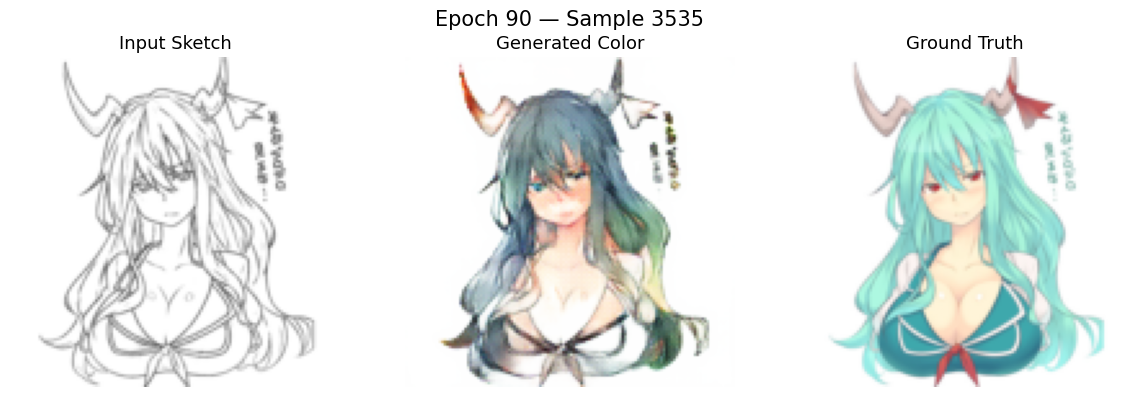

In [12]:
# ── Test Loaded Weights on a Single Sketch ────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import display
import io
import torch

# ── Pick any sketch from your validation set ─────────────────────────────
sample_idx = len(val_dataset)-10  # change this to try different images

generator.eval()
with torch.no_grad():
    sketch, real = val_dataset[sample_idx]
    sketch_input = sketch.unsqueeze(0).to(device)
    generated    = generator(sketch_input)

# ── Denormalize from [-1,1] to [0,1] ─────────────────────────────────────
sketch_vis = (sketch.permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1).numpy()
real_vis   = (real.permute(1, 2, 0)   * 0.5 + 0.5).clamp(0, 1).numpy()
gen_vis    = (generated.squeeze(0).cpu().permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1).numpy()

# ── Display ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sketch_vis);  axes[0].set_title('Input Sketch',    fontsize=13); axes[0].axis('off')
axes[1].imshow(gen_vis);     axes[1].set_title('Generated Color', fontsize=13); axes[1].axis('off')
axes[2].imshow(real_vis);    axes[2].set_title('Ground Truth',    fontsize=13); axes[2].axis('off')

plt.suptitle(f'Epoch {start_epoch} — Sample {sample_idx}', fontsize=15)
plt.tight_layout()
display(fig)       # use display() instead of plt.show()
plt.close(fig)     # close after displaying to free memory

In [ ]:
start_epoch = start_epoch if 'start_epoch' in dir() else 0
for epoch in range(start_epoch,NUM_EPOCHS):
    generator.train()
    discriminator.train()
    g_epoch_loss = d_epoch_loss = 0.0

    for i, (sketches, real_images) in enumerate(train_loader):
        sketches    = sketches.to(device, non_blocking=True)
        real_images = real_images.to(device, non_blocking=True)

        # ── Discriminator ──────────────────────────────────────
        optimizer_D.zero_grad(set_to_none=True)
        with autocast():
            real_pred    = discriminator(sketches, real_images)
            loss_D_real  = adversarial_loss(real_pred, torch.ones_like(real_pred))
            fake_images  = generator(sketches).detach()  # detach here, no separate variable needed
            fake_pred    = discriminator(sketches, fake_images)
            loss_D_fake  = adversarial_loss(fake_pred, torch.zeros_like(fake_pred))
            d_loss       = (loss_D_real + loss_D_fake) / 2

        scaler_D.scale(d_loss).backward()
        scaler_D.step(optimizer_D)
        scaler_D.update()
        d_epoch_loss += d_loss.item()

        # ── Generator ──────────────────────────────────────────
        optimizer_G.zero_grad(set_to_none=True)
        with autocast():
            fake_images  = generator(sketches)
            fake_pred    = discriminator(sketches, fake_images)
            g_adv_loss   = adversarial_loss(fake_pred, torch.ones_like(fake_pred))
            g_l1_loss    = reconstruction_loss(fake_images, real_images)
            g_loss       = g_adv_loss + L1_LAMBDA * g_l1_loss

        scaler_G.scale(g_loss).backward()
        scaler_G.step(optimizer_G)
        scaler_G.update()
        g_epoch_loss += g_loss.item()

        # NO empty_cache() here — removed entirely from batch loop

        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] Batch [{i+1}/{len(train_loader)}] "
                  f"D: {d_epoch_loss/(i+1):.4f}  G: {g_epoch_loss/(i+1):.4f}")

    # ── End of epoch ───────────────────────────────────────────
    avg_d = d_epoch_loss / len(train_loader)
    avg_g = g_epoch_loss / len(train_loader)
    d_losses.append(avg_d)
    g_losses.append(avg_g)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | D: {avg_d:.4f} | G: {avg_g:.4f}")

    # Cleanup ONCE per epoch (not per batch)
    gc.collect()
    torch.cuda.empty_cache()

    # ── Checkpoint ─────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict':     generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict':   optimizer_G.state_dict(),
            'optimizer_D_state_dict':   optimizer_D.state_dict(),
            'g_losses': g_losses,
            'd_losses': d_losses,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pth'))
        print(f"  -> Checkpoint saved at epoch {epoch+1}")

    # ── Visualization (save to file, never plt.show() in loop) ─
    if (epoch + 1) % VIZ_EVERY == 0:
        generator.eval()
        with torch.no_grad():
            sample_sketches, sample_reals = next(iter(val_loader))
            sample_sketches = sample_sketches.to(device)
            sample_fakes    = generator(sample_sketches).cpu()
            sample_sketches = sample_sketches.cpu()

        fig, axes = plt.subplots(3, 4, figsize=(16, 12))
        for j in range(4):
            axes[0, j].imshow((sample_sketches[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[0, j].set_title('Sketch');  axes[0, j].axis('off')
            axes[1, j].imshow((sample_fakes[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[1, j].set_title('Generated'); axes[1, j].axis('off')
            axes[2, j].imshow((sample_reals[j].permute(1,2,0) * 0.5 + 0.5).clamp(0,1))
            axes[2, j].set_title('Ground Truth'); axes[2, j].axis('off')

        plt.suptitle(f'Epoch {epoch+1}')
        plt.tight_layout()
        plt.savefig(f'/kaggle/working/samples_epoch_{epoch+1}.png',  # save to file
                    dpi=100, bbox_inches='tight')
        plt.close(fig)   # CRITICAL: close figure to free memory, never plt.show()
        del sample_sketches, sample_fakes, sample_reals
        gc.collect()
        torch.cuda.empty_cache()
        generator.train()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generator loss curve
axes[0].plot(range(1, len(g_losses) + 1), g_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Generator Loss vs Epochs')
axes[0].grid(True, alpha=0.3)

# Discriminator loss curve
axes[1].plot(range(1, len(d_losses) + 1), d_losses, color='indianred', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Discriminator Loss vs Epochs')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# also plot them together for comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(g_losses) + 1), g_losses, label='Generator', color='steelblue', linewidth=1.5)
plt.plot(range(1, len(d_losses) + 1), d_losses, label='Discriminator', color='indianred', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator vs Discriminator Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Generator Loss:     {g_losses[-1]:.4f}")
print(f"Final Discriminator Loss: {d_losses[-1]:.4f}")

In [ ]:
def denormalize(tensor):
    """Convert from [-1,1] range back to [0,1] for metric computation."""
    return (tensor + 1.0) / 2.0


generator.eval()
ssim_scores = []
psnr_scores = []

print("Computing SSIM and PSNR on validation set...")

with torch.no_grad():
    for i, (sketches, real_images) in enumerate(val_loader):
        sketches = sketches.to(device)
        real_images = real_images.to(device)

        # generate colorized outputs
        generated = generator(sketches)

        # move to CPU, denormalize to [0,1], convert to numpy
        gen_np = denormalize(generated).cpu().numpy()
        real_np = denormalize(real_images).cpu().numpy()

        # compute metrics for each image in the batch
        for j in range(gen_np.shape[0]):
            # transpose (C, H, W) -> (H, W, C) for skimage
            gen_img = gen_np[j].transpose(1, 2, 0).clip(0, 1)
            real_img = real_np[j].transpose(1, 2, 0).clip(0, 1)

            # SSIM: structural similarity (luminance, contrast, structure)
            # range 0-1, higher is better
            ssim_val = ssim(real_img, gen_img, data_range=1.0, channel_axis=2)
            ssim_scores.append(ssim_val)

            # PSNR: peak signal-to-noise ratio
            # higher is better, typically 20-40 dB for generated images
            psnr_val = psnr(real_img, gen_img, data_range=1.0)
            psnr_scores.append(psnr_val)

    # print progress
    if (i + 1) % 10 == 0:
        print(f"  Processed {(i+1) * BATCH_SIZE} images...")

print("=" * 50)
print(f"Evaluated on {len(ssim_scores)} images")
print(f"Average SSIM: {np.mean(ssim_scores):.4f} (+/- {np.std(ssim_scores):.4f})")
print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB (+/- {np.std(psnr_scores):.2f})")
print("=" * 50)

In [ ]:
def visualize_results(gen, loader, num_samples=10):
    """Display input sketch, generated output, and ground truth side by side."""
    gen.eval()

    # grab one batch from the validation set
    sketches, real_images = next(iter(loader))
    sketches = sketches.to(device)

    with torch.no_grad():
        generated = gen(sketches)

    # denormalize everything to [0,1] for display
    sketches_vis = (sketches.cpu() * 0.5 + 0.5).clamp(0, 1)
    generated_vis = (generated.cpu() * 0.5 + 0.5).clamp(0, 1)
    real_vis = (real_images * 0.5 + 0.5).clamp(0, 1)

    # limit to available samples in the batch
    num_samples = min(num_samples, sketches_vis.size(0))

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    # handle case where num_samples is 1 (axes wouldn't be 2D)
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # input sketch
        axes[i, 0].imshow(sketches_vis[i].permute(1, 2, 0))
        axes[i, 0].set_title('Input Sketch', fontsize=12)
        axes[i, 0].axis('off')

        # generated colorized image
        axes[i, 1].imshow(generated_vis[i].permute(1, 2, 0))
        axes[i, 1].set_title('Generated Output', fontsize=12)
        axes[i, 1].axis('off')

        # ground truth
        axes[i, 2].imshow(real_vis[i].permute(1, 2, 0))
        axes[i, 2].set_title('Ground Truth', fontsize=12)
        axes[i, 2].axis('off')

    plt.suptitle('Pix2Pix Results: Sketch to Colorized Anime', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('generated_samples.png', dpi=150, bbox_inches='tight')
    plt.show()


# run the visualization on validation data
visualize_results(generator, val_loader, num_samples=10)

In [ ]:
!pip install huggingface_hub --quiet
from huggingface_hub import HfApi, login, create_repo, list_repo_files
import io, torch, torch.nn as nn
from kaggle_secrets import UserSecretsClient

# ── Auth ──────────────────────────────────────────────────────────────────
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)
api     = HfApi()
REPO_ID = 'adeelumar17/pix2pix'

# ── Create repo ───────────────────────────────────────────────────────────
create_repo(
    repo_id   = REPO_ID,
    repo_type = 'model',
    private   = True,
    exist_ok  = True
)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')

# ── Serialize to memory ───────────────────────────────────────────────────
buf = io.BytesIO()
g = generator.module     if isinstance(generator,     nn.DataParallel) else generator
d = discriminator.module if isinstance(discriminator, nn.DataParallel) else discriminator

# Get current epoch from your loss tracking
current_epoch = 100

torch.save({
    'epoch'                    : current_epoch,
    'generator_state_dict'     : g.state_dict(),       # matched to your checkpoint key names
    'discriminator_state_dict' : d.state_dict(),
    'optimizer_G_state_dict'   : optimizer_G.state_dict(),
    'optimizer_D_state_dict'   : optimizer_D.state_dict(),
    'g_losses'                 : g_losses,             # save loss history too
    'd_losses'                 : d_losses,
}, buf)

size_mb = buf.tell() / 1e6
buf.seek(0)
print(f'Checkpoint size: {size_mb:.0f} MB — uploading...')

# ── Upload directly from memory ───────────────────────────────────────────
api.upload_file(
    path_or_fileobj = buf,
    path_in_repo    = f'checkpoint_epoch_{current_epoch}.pth',  # dynamic filename
    repo_id         = REPO_ID,
    repo_type       = 'model',
    commit_message  = f'checkpoint upload — epoch {current_epoch}'
)
print(f'Upload complete: https://huggingface.co/{REPO_ID}')
print('Files in your HuggingFace repo:')
for f in list_repo_files(repo_id=REPO_ID, repo_type='model', token=HF_TOKEN):
    print(f'  {f}')

In [ ]:
!pip install huggingface_hub --quiet
from huggingface_hub import HfApi, login, create_repo, list_repo_files
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)
api     = HfApi()
REPO_ID = 'adeelumar17/pix2pix'

create_repo(repo_id=REPO_ID, repo_type='model', private=True, exist_ok=True)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')

# ── Upload directly from disk ─────────────────────────────────────────────
checkpoint_to_upload = '/kaggle/working/checkpoints/checkpoint_epoch_90.pth'

api.upload_file(
    path_or_fileobj = checkpoint_to_upload,
    path_in_repo    = 'checkpoint_epoch_90.pth',
    repo_id         = REPO_ID,
    repo_type       = 'model',
    commit_message  = 'checkpoint upload — epoch 85'
)
print(f'Upload complete: https://huggingface.co/{REPO_ID}')
print('Files in your HuggingFace repo:')
for f in list_repo_files(repo_id=REPO_ID, repo_type='model', token=HF_TOKEN):
    print(f'  {f}')